In [5]:
title = "# Introduction to Bayesian statistics: exercises"
# Print title and setup TeX defs for both KaTeX and MathJax
import bayesian_stats_course_tools
bayesian_stats_course_tools.misc.display_markdown_and_setup_tex(title)
import numpy as np
import matplotlib.style
matplotlib.style.use("bayesian_stats_course_tools.light")
import matplotlib.pyplot as plt

# Introduction to Bayesian statistics: exercises

<!-- Define LaTeX macros -->
$\def\E{\operatorname{E}}$
$\def\Var{\operatorname{Var}}$
$\def\Cov{\operatorname{Cov}}$
$\def\dd{\mathrm{d}}$
$\def\ee{\mathrm{e}}$
$\def\Norm{\mathcal{N}}$
$\def\Uniform{\mathcal{U}}$
$\def\GP{\mathcal{GP}}$

<!-- MathJax needs them to be defined again for the non-inline environment -->
$$\def\E{\operatorname{E}}$$
$$\def\Var{\operatorname{Var}}$$
$$\def\Cov{\operatorname{Cov}}$$
$$\def\dd{\mathrm{d}}$$
$$\def\ee{\mathrm{e}}$$
$$\def\Norm{\mathcal{N}}$$
$$\def\Uniform{\mathcal{U}}$$
$$\def\GP{\mathcal{GP}}$$

# Exercise 1

- Implement your own version of the line-fitting procedure, using the same data.
- Now try it with the data in `lectures/data/linear_fits/data_1.txt`
    - First plot the data. What has changed?
    - Try the same model and likelihood on the new data. You might want to adjust the prior on $m$ and $b$ for this new data set.
    - What if you use the provided uncertainty per data point $\sigma_{y_i}$, instead of assuming a constant variance $\sigma_y$ for all data points?
    - Instead use the actual likelihood of the data:
\begin{align}
    \mu(x) &= mx + b \\
    \sigma(x_i) &= \sigma_{y_i} + f\mu(x_i)^2 \quad f > 0\ \text{a parameter} \\
    y_i&\sim\mathcal N(\mu(x_i),\sigma(x_i)^2)
\end{align}
Careful with the normalisation of the Gaussian likelihood. Because we vary the variance, this matters now!

In [21]:
def plot_linear_data_set(x, y, y_err=None):
    """Plot linear data set and format the plot."""
    fig, ax = plt.subplots(1, 1)

    if y_err is not None:
        ax.errorbar(x, y, y_err, fmt=".", label="Data")
    else:
        ax.plot(x, y, marker=".", linestyle="none", label="Data")

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")
    ax.legend(loc="upper left")

    return fig, ax

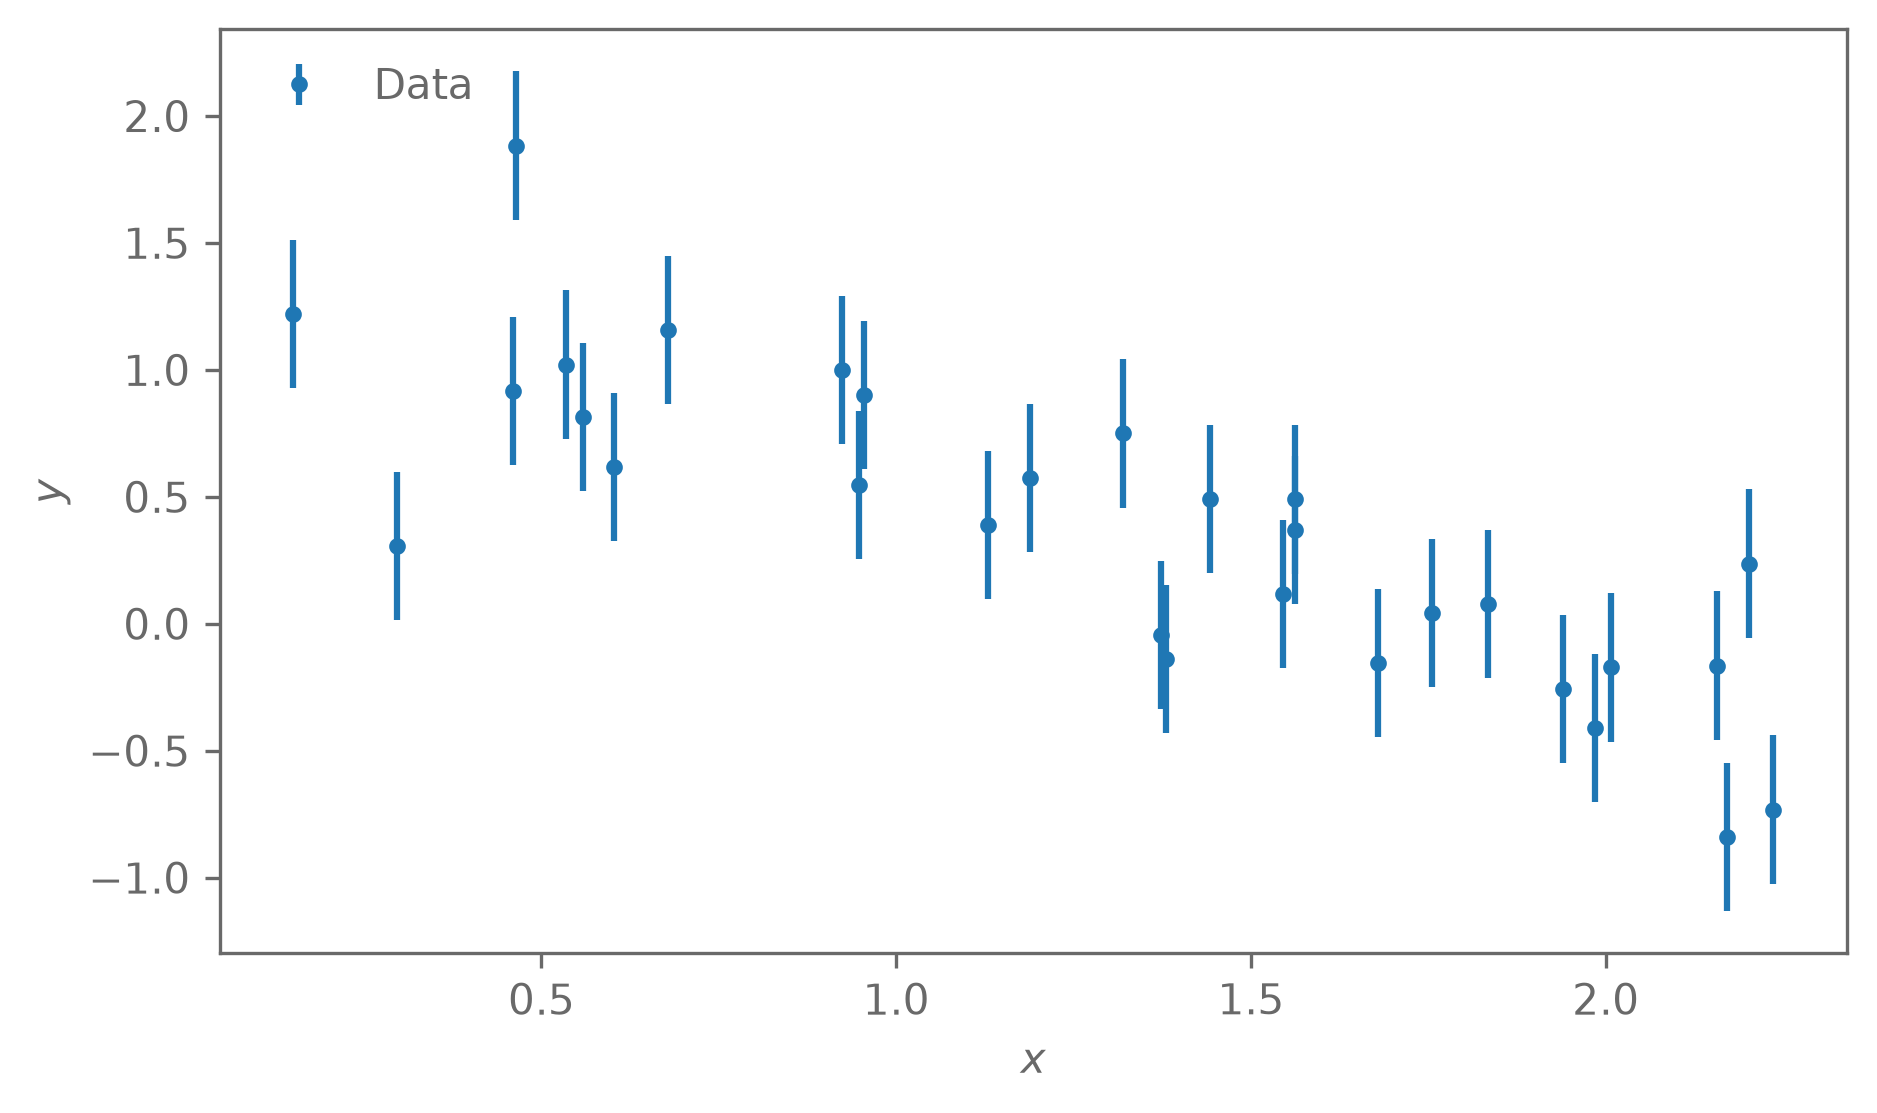

In [22]:
import os
path=os.path.join("C:\\Users\\maxi\\OneDrive - ETH Zurich\\7. Semester HS 26\\Bayesian Statistics\\Repository\\Bayesian-Stats-HS2026\\lectures\\data\\linear_fits\\data_1.txt")
data=np.loadtxt(path)
x=data[:,0]
y=data[:,1]
y_err=data[:,2]
# For now, all errors are the same
sigma_y = y_err[0]

_ = plot_linear_data_set(x, y, sigma_y)

1. Tote Daten,weirder Punkt, geht runter

In [53]:
def model(m, b, x):
    return m*x + b

# Probability of the data, given the model parameters: P(y|m, b)
# We use the logarithm here for computational reasons
def log_likelihood_probability(y, m, b, x, sigma_y):
    prediction = model(m, b, x)

    n = len(y)
    # log of the PDF of a multivariate Gaussian
    return (
        -0.5 * np.sum((y - prediction)**2/sigma_y**2  # Exponent
        - n/2*np.log(2*np.pi*sigma_y**2)        )       # Normalisation
    )
import scipy
m_prior = scipy.stats.norm(loc=-0.7, scale=1)
b_prior = scipy.stats.norm(loc=1, scale=1.2)

def log_prior_probability(m, b):
    return m_prior.logpdf(m) + b_prior.logpdf(b)

def updated_prior(r):
    return posterior(r, k=2, t=5)

def updated_posterior(r, k, t):
    return likelihood(k, t, r) * updated_prior(r)

n = 10

def likelihood(k, t, r):
    theta = r/n
    return scipy.special.binom(t, k) * theta**k * (1-theta)**(t-k)

def prior(r):
    p = 1/(n+1)
    return p * np.ones_like(r)  # Make prior(r) play nice if r is an array

def posterior(r, k, t):
    return likelihood(k, t, r) * prior(r)

In [54]:
def sample_prior(n_sample):
    """Sample n_sample times from the prior distribution."""
    return np.vstack((m_prior.rvs(n_sample), b_prior.rvs(n_sample))).T

# Fix the pseudo random number generator seed for reproducibility
np.random.seed(42)

# Evaluate the model at the prior sample parameters
prior_model_predictive = np.array(
    [model(*parameters, x) for parameters in sample_prior(n_sample=20)]
)

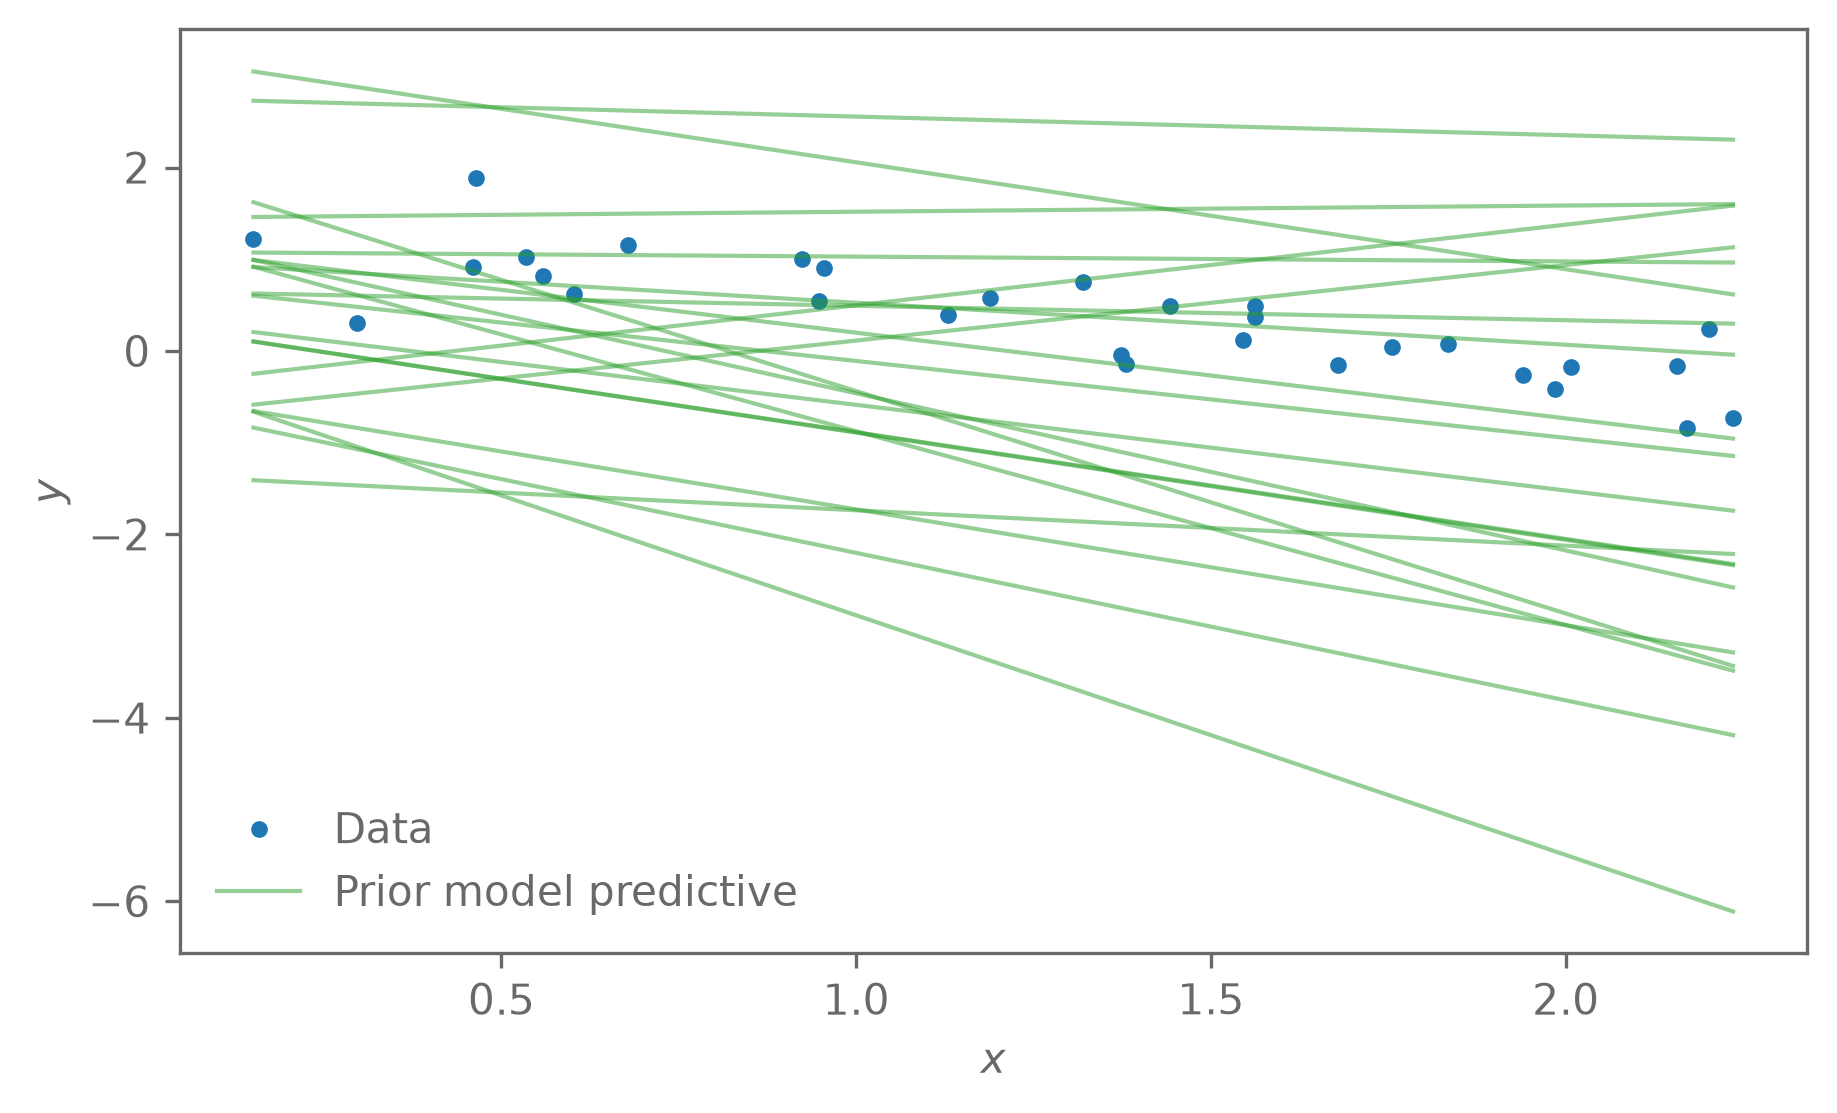

In [55]:
_, ax = plot_linear_data_set(x, y)

style = dict(c="C2", lw=1, alpha=0.5)
ax.plot(x, prior_model_predictive.T, **style)
ax.plot([], [], label="Prior model predictive", **style)
ax.legend();

This looks reasonable! Let us also check that data created based on these models look reasonable as well:

In [56]:
# Since we have a Gaussian likelihood, we can add Gaussian noise with the 
# correct variance to our prior model predictions
prior_predictive = (
    prior_model_predictive
    + sigma_y*np.random.normal(size=prior_model_predictive.shape)
)

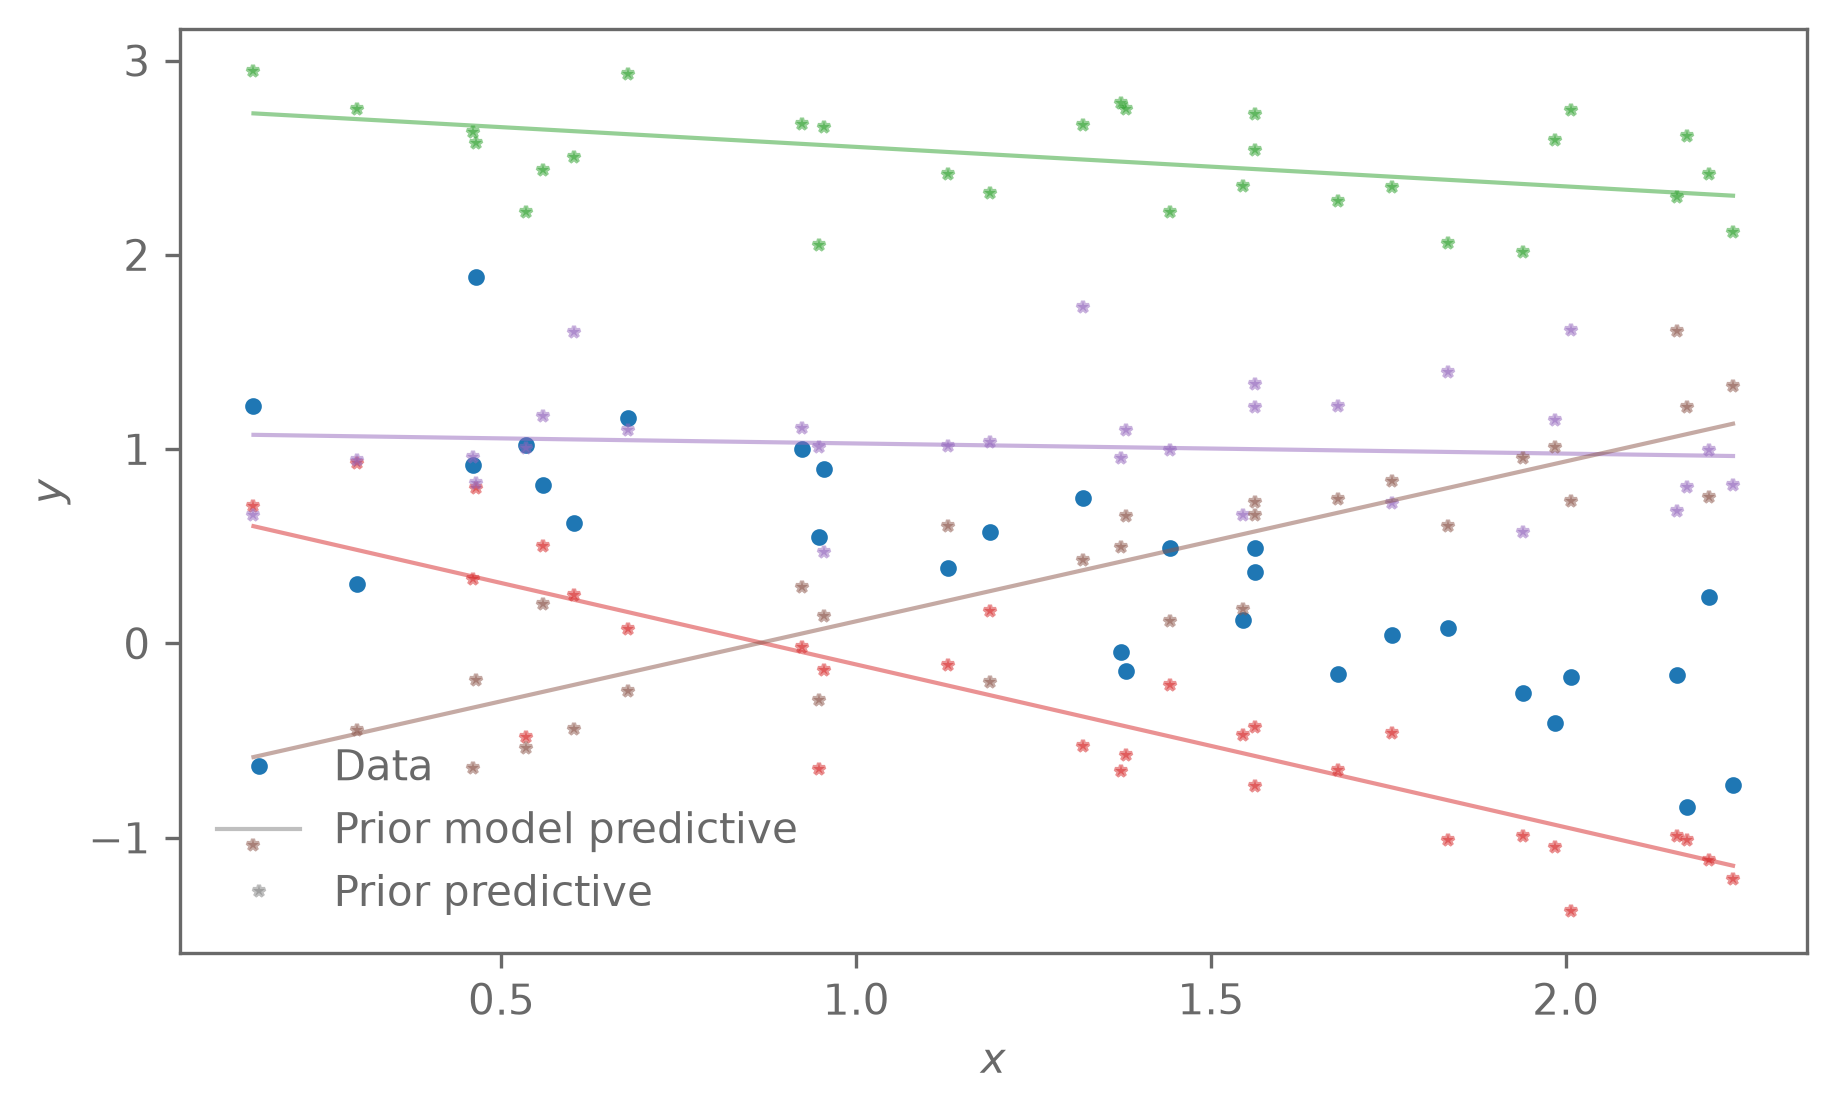

In [57]:
_, ax = plot_linear_data_set(x, y)

pmp_style = dict(lw=1, alpha=0.5)
pp_style = dict(ls="none", marker="*", ms=3, alpha=0.5)

for i in range(4):
    ax.plot(x, prior_model_predictive[i], c=f"C{i+2}", **pmp_style)
    ax.plot(x, prior_predictive[i], c=f"C{i+2}", **pp_style)

ax.plot([], [], label="Prior model predictive", c="grey", **pmp_style)
ax.plot([], [], label="Prior predictive", c="grey", **pp_style)
ax.legend();

2. Fit the model

In [58]:
def log_posterior_probability(m, b, x, sigma_y, y):
    return (
        log_likelihood_probability(y, m, b, x, sigma_y)
        + log_prior_probability(m, b)
    )

In [59]:
# The scipy minimizer finds the minimum, so we need to take the 
# negative of the posterior. The scipy minimizer also passes an array 
# with the parameters, this wrapper splits this array into m and b.
def negative_log_posterior(theta, x, sigma_y, y):
    m, b = theta
    return -log_posterior_probability(m, b, x, sigma_y, y)

MAP_result = scipy.optimize.minimize(
    fun=negative_log_posterior,
    x0=(1, 0),
    args=(x, sigma_y, y)
)
m_MAP, b_MAP = MAP_result.x

print("MAP results")
print(f"m_MAP = {m_MAP:.3f}, b_MAP = {b_MAP:.3f}")

MAP results
m_MAP = -0.790, b_MAP = 1.394


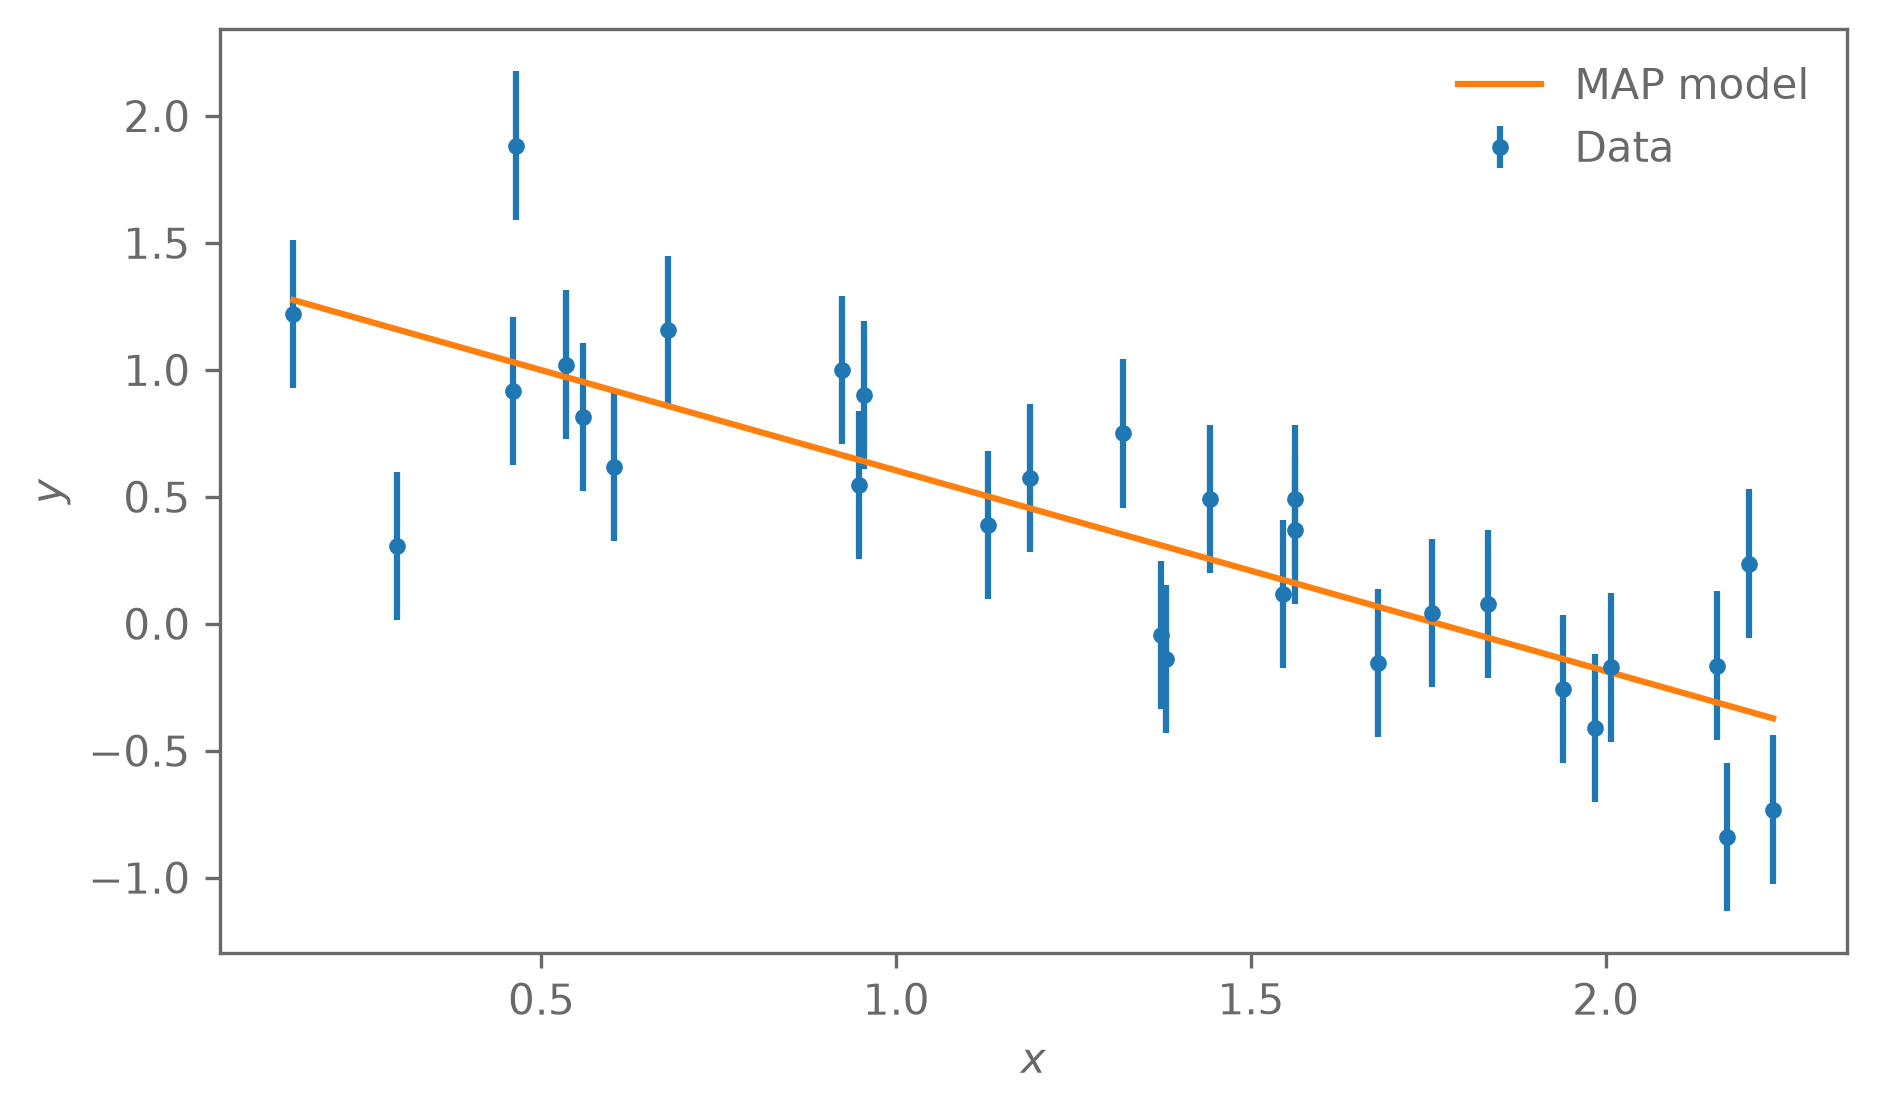

In [60]:
_, ax = plot_linear_data_set(x, y, sigma_y)

x_grid = np.linspace(0, 2.5, 100)
ax.plot(x, model(m_MAP, b_MAP, x), c="C1", label="MAP model")
ax.legend();

# Exercise 2

The data in the previous example were a synthetic version of real observations that were obtained in an AstroWoche project in 2024 by Jonas Spiller, Theo Lequy, Clara Bleich. 

<!-- ![jovian moons data](../assets/jovian_moons_raw_data.png) -->
<img style="display: block; 
    margin-left: auto;
    margin-right: auto;
    width: 60%;"
    src="../assets/jovian_moons_raw_data.png" alt="jovian moons data"/>

The real observations can be found in `data/jovian_moons/{moon}.dat`:

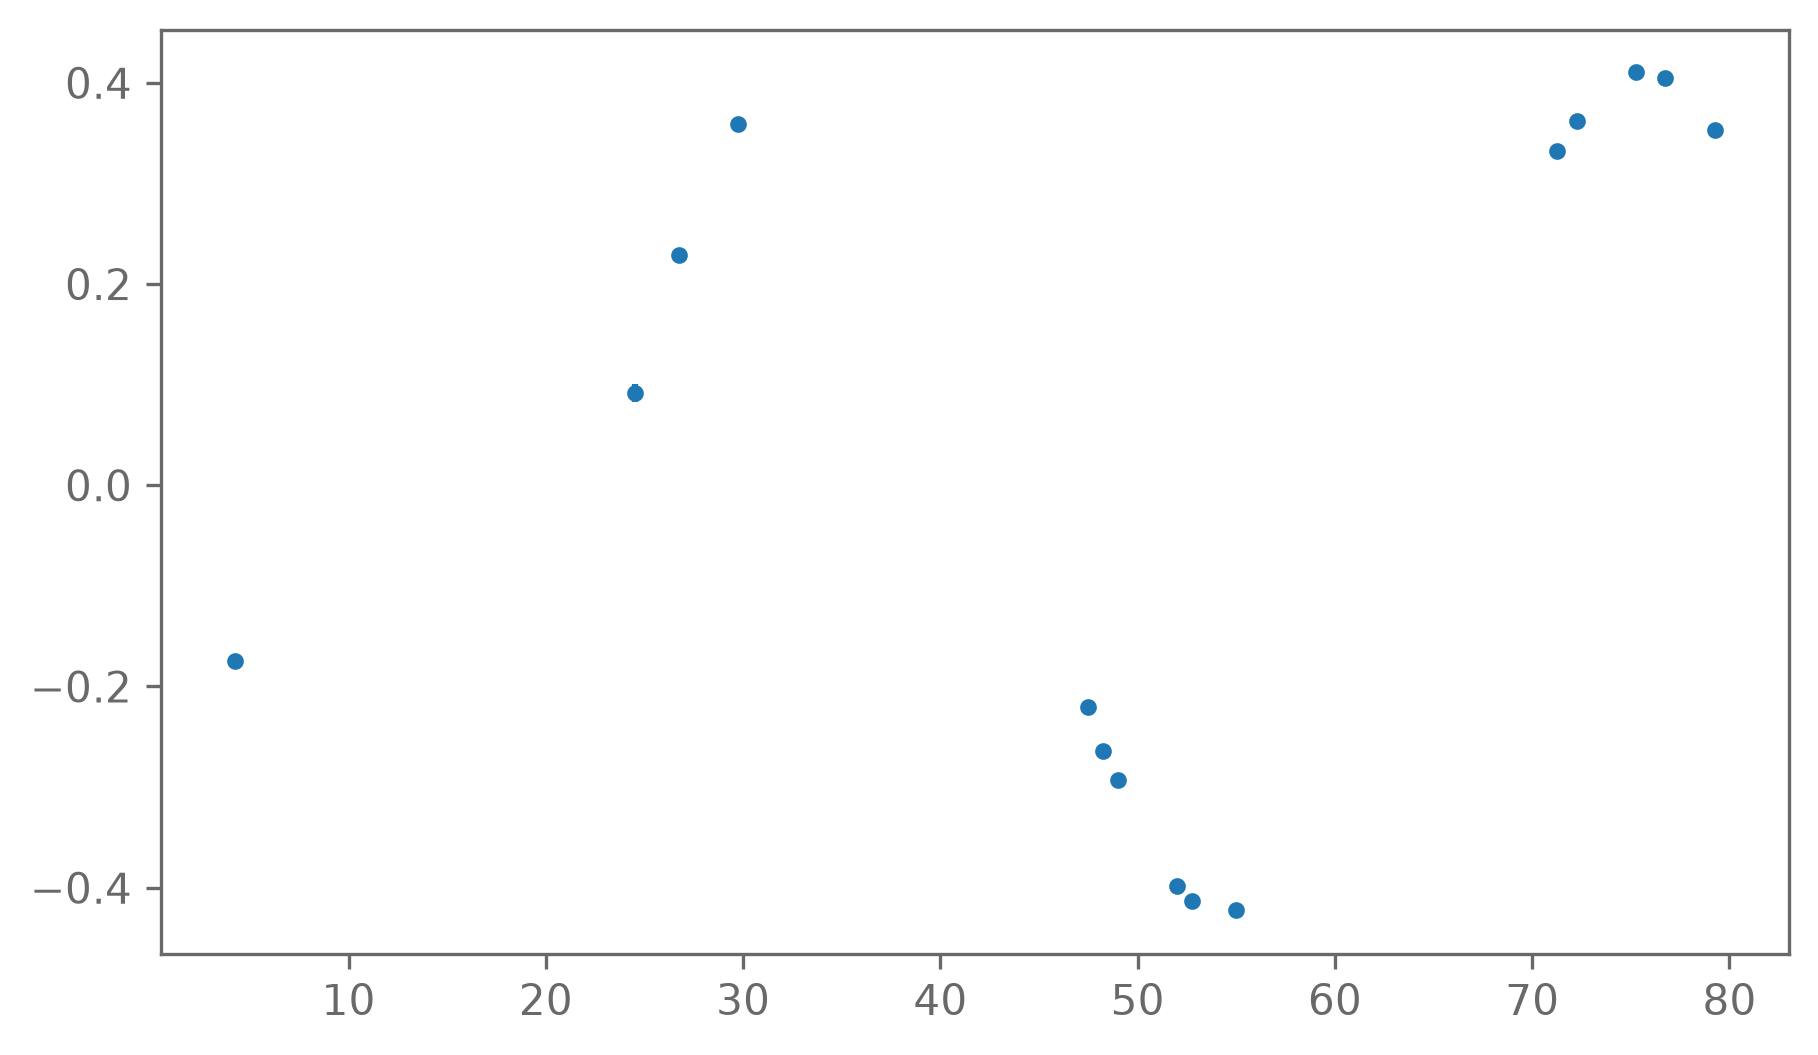

In [118]:
moon = "Io"

t, distance, distance_alt, distance_err = np.loadtxt(
    f"../lectures/data/jovian_moons/{moon}.dat", unpack=True)

plt.errorbar(t,distance,yerr=distance_err,fmt='.')
sigma_y=distance_err
n_sample=len(t)

1. Repeat the analysis with the real data set. What do you find?

In [151]:
def model(R,T,phi,t):
    return R*np.sin(2*np.pi/T*t+phi)

def log_likelihood_probability(y,R,T,phi,t, sigma_y):
    prediction = model(R,T,phi,t)

    n = len(y)
    # log of the PDF of a multivariate Gaussian
    return (
        -0.5 * np.sum((y - prediction)**2/sigma_y**2  # Exponent
        - n/2*np.log(2*np.pi*sigma_y**2)        )       # Normalisation
    )

R_prior = scipy.stats.norm(loc=0.4, scale=0.1)
T_prior = scipy.stats.norm(loc=70, scale=15)
phi_prior = scipy.stats.norm(loc=-12/(2*np.pi), scale=0.3*np.pi)


def log_prior_probability(R,T,phi):
    return R_prior.logpdf(R) + T_prior.logpdf(T)+phi_prior.logpdf(phi)

def updated_prior(r):
    return posterior(r, k=2, t=5)

def updated_posterior(r, k, t):
    return likelihood(k, t, r) * updated_prior(r)

n = 10

def likelihood(k, t, r):
    theta = r/n
    return scipy.special.binom(t, k) * theta**k * (1-theta)**(t-k)

def prior(r):
    p = 1/(n+1)
    return p * np.ones_like(r)  # Make prior(r) play nice if r is an array

def posterior(r, k, t):
    return likelihood(k, t, r) * prior(r)

In [152]:
def sample_prior(n_sample):
    """Sample n_sample times from the prior distribution."""
    return np.vstack((R_prior.rvs(n_sample), T_prior.rvs(n_sample),phi_prior.rvs(n_sample))).T

# Fix the pseudo random number generator seed for reproducibility
np.random.seed(42)

flip=np.linspace(0,80,1000)
# Evaluate the model at the prior sample parameters
prior_model_predictive_cont = np.array(
    [model(*parameters, flip) for parameters in sample_prior(n_sample=100)]
)
prior_model_predictive_dis = np.array(
    [model(*parameters, t) for parameters in sample_prior(n_sample=100)]
)

C:\Users\maxi\AppData\Local\Temp\ipykernel_7624\2597428160.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend();


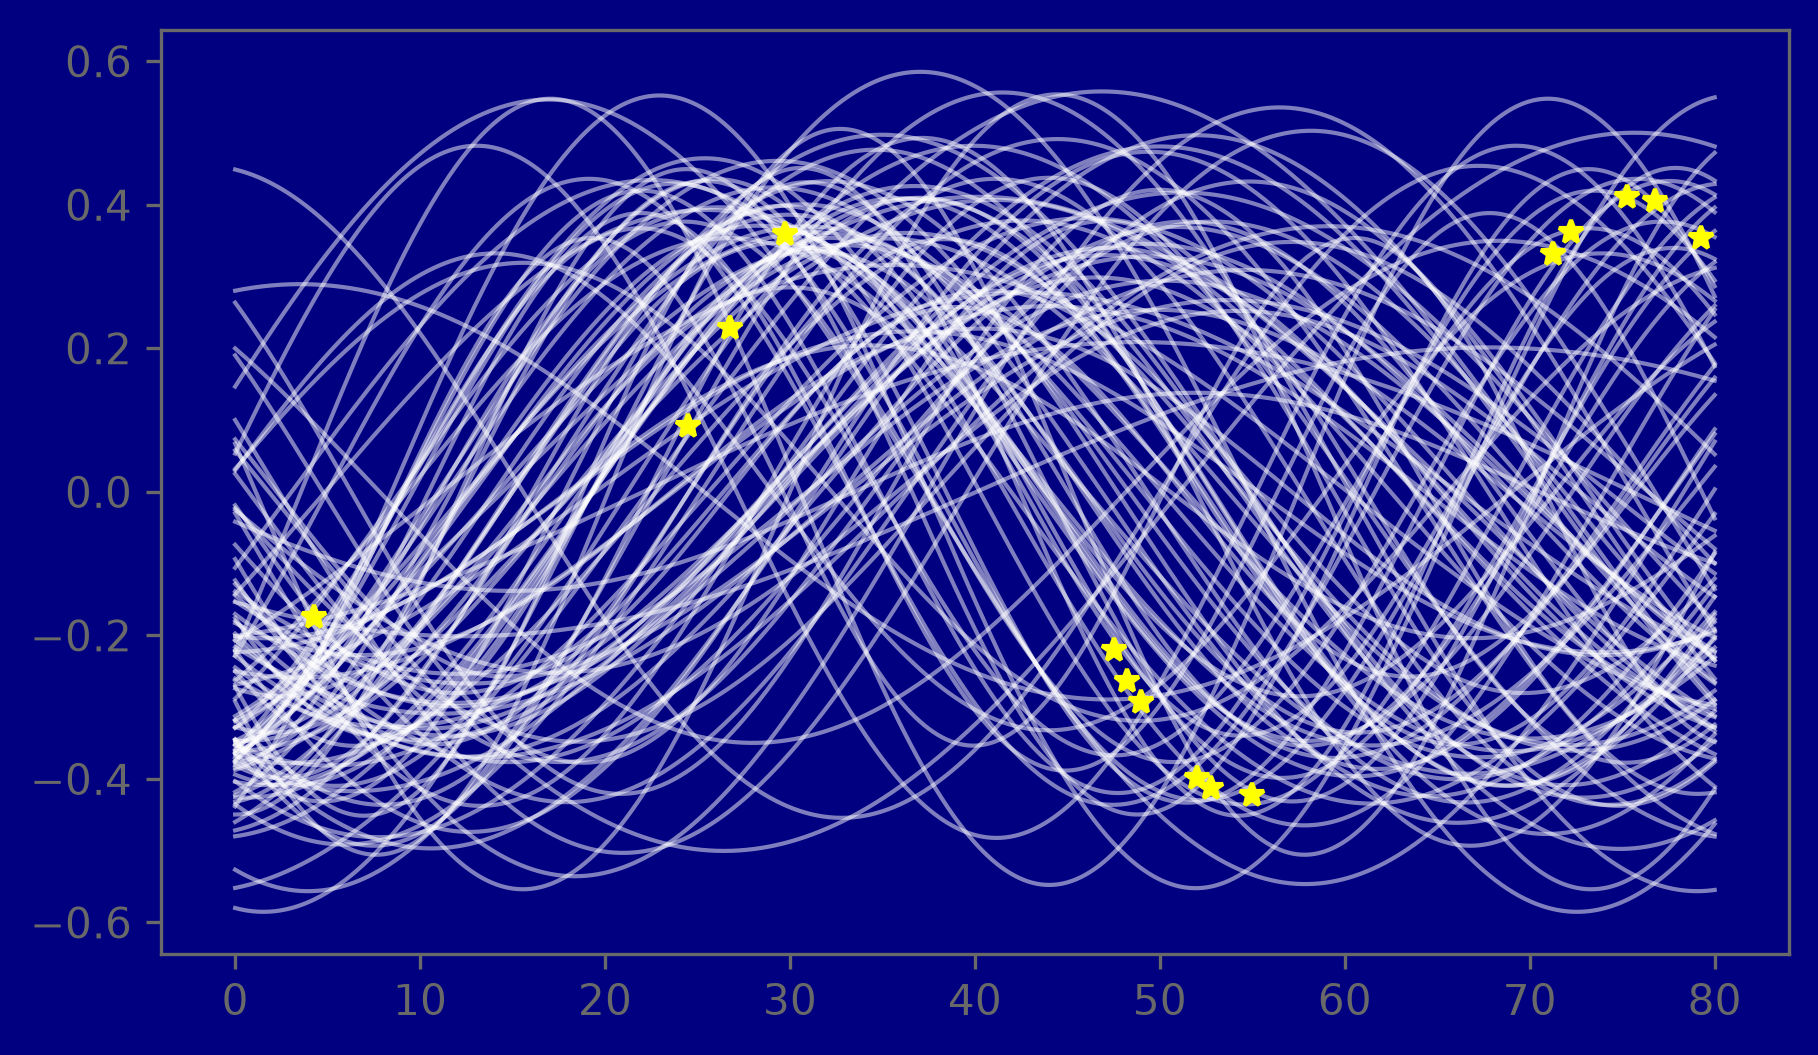

In [153]:
fig=plt.figure()
fig.patch.set_facecolor('navy')
ax=fig.subplots()
style = dict(c="white", lw=1, alpha=0.5)
ax.plot(flip, prior_model_predictive_cont.T, **style)
ax.errorbar(t,distance,yerr=distance_err,fmt='*',color="yellow")
ax.legend();

In [154]:
prior_predictive_dis = (
    prior_model_predictive_dis
    + sigma_y*np.random.normal(size=prior_model_predictive_dis.shape)
)

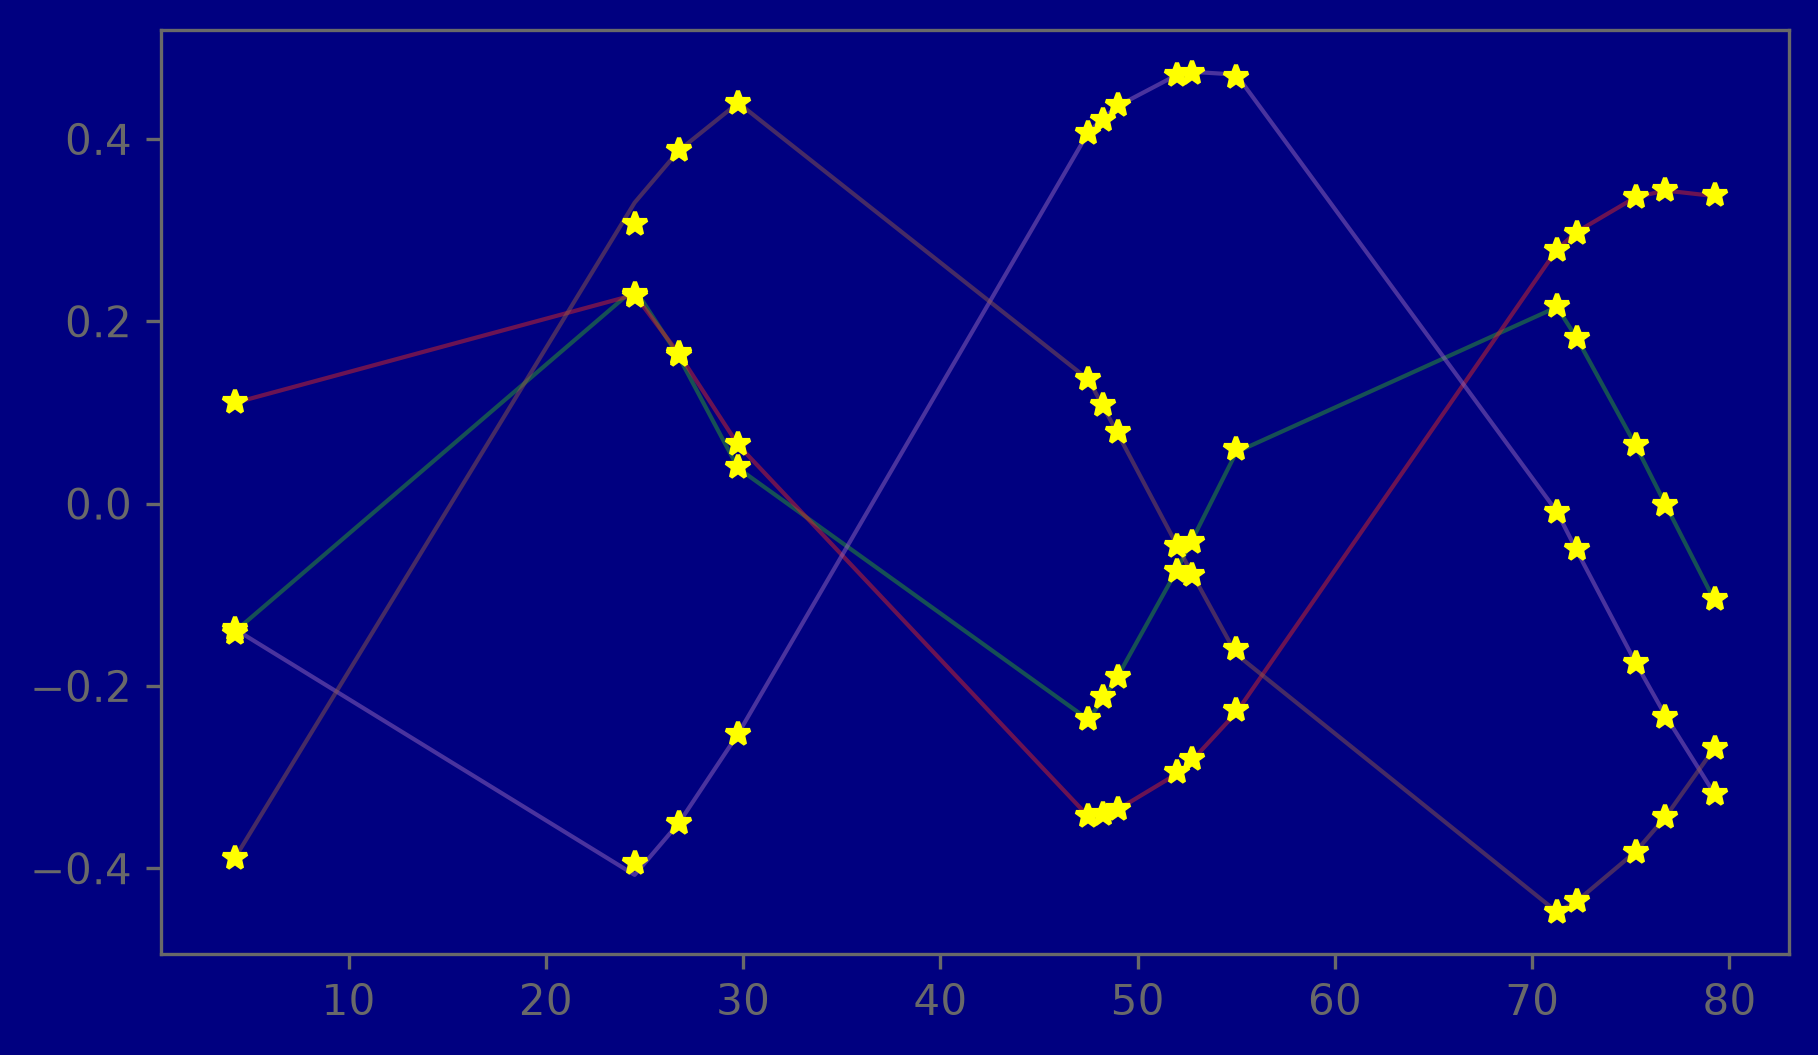

In [155]:
fig=plt.figure()
fig.patch.set_facecolor('navy')
ax=fig.subplots()

for i in range(4):
    ax.plot(t, prior_model_predictive_dis[i], c=f"C{i+2}", **pmp_style)
    ax.errorbar(t, prior_predictive_dis[i],yerr=0, color="yellow", fmt='*')

In [156]:
def log_posterior_probability(R,T,phi,t, sigma_y, distance):
    return (
        log_likelihood_probability(distance,R,T,phi,t, sigma_y)
        + log_prior_probability(R,T,phi)
    )

In [157]:
# The scipy minimizer finds the minimum, so we need to take the 
# negative of the posterior. The scipy minimizer also passes an array 
# with the parameters, this wrapper splits this array into m and b.
def negative_log_posterior(theta, t, sigma_y, distance):
    R,T,phi = theta
    return -log_posterior_probability(R,T,phi,t, sigma_y, distance)

MAP_result = scipy.optimize.minimize(
    fun=negative_log_posterior,
    x0=(0.4,70,-12/(2*np.pi)),
    args=(t, sigma_y, distance)
)
R_MAP, T_MAP, phi_MAP = MAP_result.x

print("MAP results")
print(f"R_MAP = {R_MAP:.3f}, T_MAP = {T_MAP:.3f}")

MAP results
R_MAP = -0.414, T_MAP = 42.408


There is another distance estimate provided. The difference between the distance estimates comes from different approaches to converting the measured distance between Jupiter and its moons from the number of pixels to a physical distance in km.

2. How does the analysis look when using this other distance estimate (what I call `distance_alt`)? What about the other moons?



Because there are two distance estimates that do not agree, both of which are based on reasonable approaches, this suggests that there might be a _systematic_ error in the measurements. Systematic errors are usually not random (which means they do not get smaller as you obtain more data). But we could pretend the offset between the two measurements is an estimate of an unaccounted statistical uncertainty. 

3. How does the analysis look when we assume `sigma_d**2 = distance_err**2 + (distance - distance_alt)**2`?



4. Instead of assuming that the uncertainty is underestimated by this offset, we can also model it. Does the model work better if the variance is a free parameter?
